In [3]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns
from jax import random
from scipy.linalg import eigvalsh
from ntk import compute_ntk_2layer_montecarlo_random_field, sin, sin_dot
from tqdm import tqdm

# Experiment: 2-Layer NTK Analysis with ReLU Activation

We analyze the Neural Tangent Kernel for a 2-layer network with ReLU activation:
1. Compute NTK matrices for different (sigma_A, sigma_c) configurations
2. Plot the resulting matrices and their eigenvalue spectra
3. Analyze projection onto a*I + b*J subspace

Overall Progress:   0%|          | 0/5 [00:00<?, ?it/s]


Testing rank[0]=3


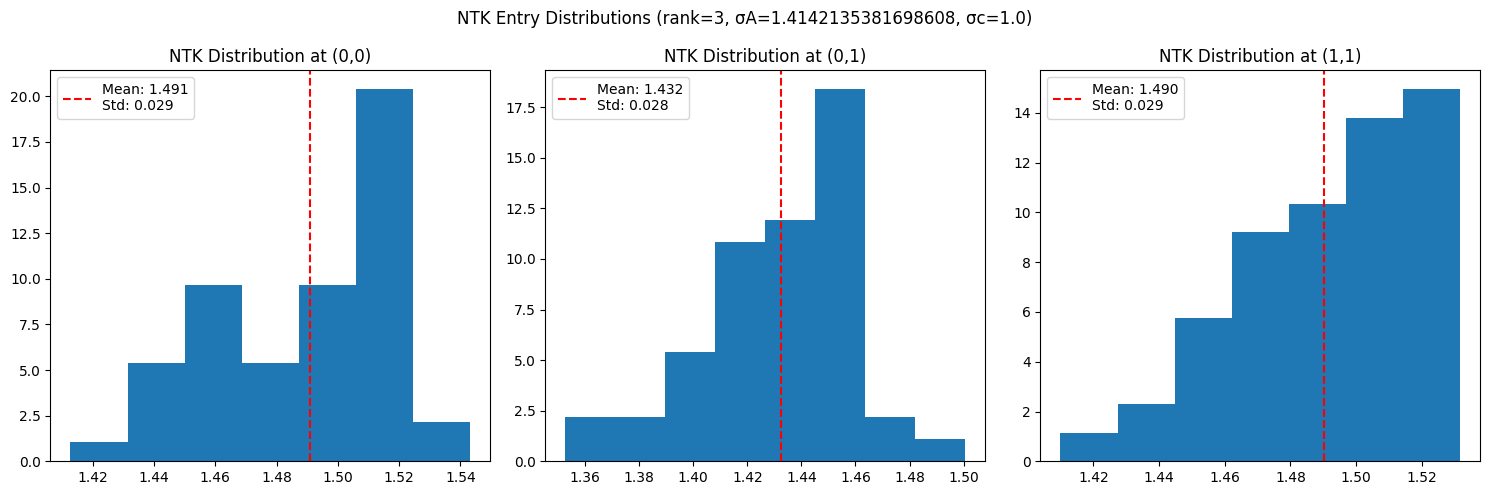

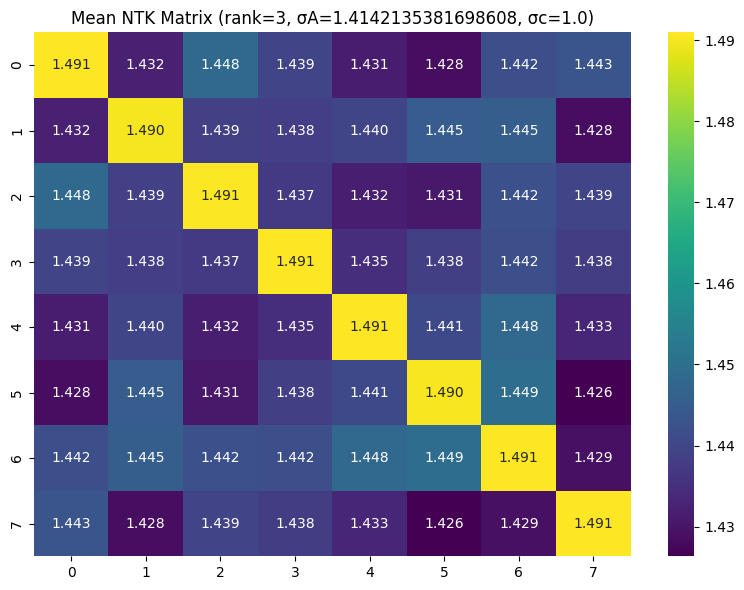

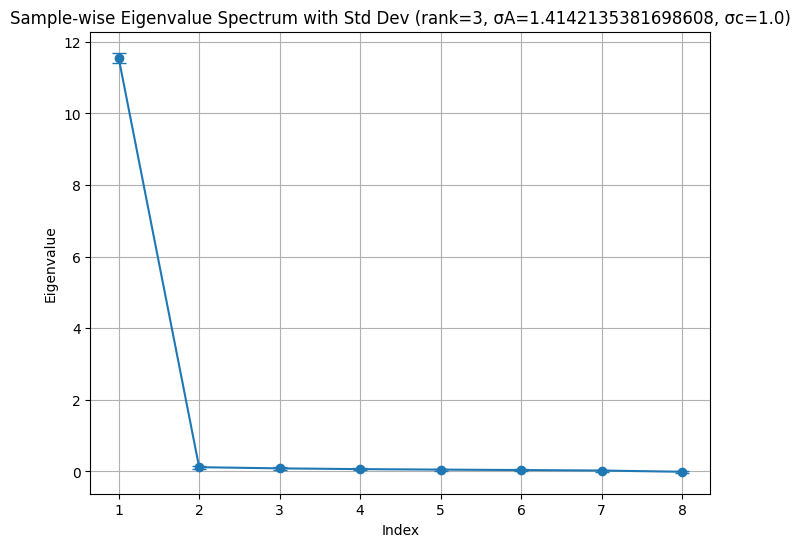

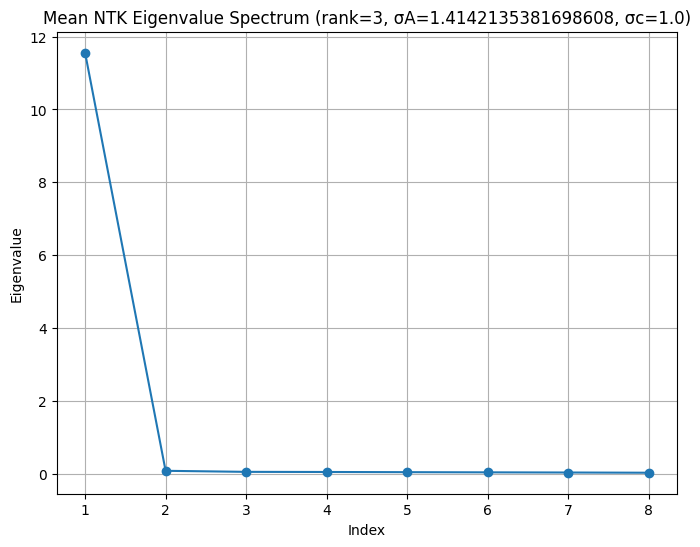

Overall Progress:  20%|██        | 1/5 [00:25<01:43, 25.83s/it]

Mean min eigenvalue: -0.010 ± 0.032
Mean max eigenvalue: 11.556 ± 0.139
Mean condition number: -624.253
Mean L2 loss: 0.013 ± 0.004
Mean NTK L2 loss: 0.004
Mean I coordinate: 0.365 ± 0.006
Mean NTK I coordinate: 0.365
Mean J coordinate: 0.931 ± 0.002
Mean NTK J coordinate: 0.931

Testing rank[0]=8


Overall Progress:  20%|██        | 1/5 [00:46<03:05, 46.28s/it]


KeyboardInterrupt: 

In [4]:
# we set up base parameters
key = random.PRNGKey(42)
input_dim = 5  # we fix input dimension
n_samples = 8  # we fix sample size
ranks_to_test = range(3,25,5) # we test different ranks[0] values
beta = 1.0  # we fix random bias scaling
n_mc_samples = 300  # we fix number of Monte Carlo samples

# we test different sigma_A and sigma_c combinations
sigma_As = [jnp.sqrt(2)]
sigma_cs = [1.0]

# we generate test data
X = random.normal(key, (n_samples, input_dim))
X = X / jnp.linalg.norm(X, axis=1, keepdims=True)  # we normalize to unit sphere

# we store l2 losses and coordinates for each rank
l2_losses = {rank: [] for rank in ranks_to_test}
i_coords = {rank: [] for rank in ranks_to_test}  # we store I coordinates
j_coords = {rank: [] for rank in ranks_to_test}  # we store J coordinates

# we store std of NTK entries
ntk_stds_00 = {rank: [] for rank in ranks_to_test}  # we store std of (0,0) entry
ntk_stds_01 = {rank: [] for rank in ranks_to_test}  # we store std of (0,1) entry

def compute_projection_matrices(n):
    """we compute normalized I and J matrices for projection"""
    I = jnp.eye(n)
    J = jnp.ones((n,n)) - jnp.eye(n)
    I_norm = jnp.linalg.norm(I, 'fro')
    J_norm = jnp.linalg.norm(J, 'fro')
    return I/I_norm, J/J_norm

def project_onto_IJ_space(K, I_norm, J_norm):
    """we project matrix K onto span{I,J}"""
    K_norm = jnp.linalg.norm(K, 'fro')
    K = K/K_norm  # we normalize K
    
    # we compute coefficients
    a = jnp.sum(K * I_norm)
    b = jnp.sum(K * J_norm)
    
    # we compute projection
    proj = a*I_norm + b*J_norm
    
    # we compute L2 loss
    l2_loss = jnp.linalg.norm(K - proj, 'fro')
    return l2_loss, a, b

# we compute and plot NTK matrices for each configuration
n_samples_ntk = 50  # we fix number of samples for NTK distribution analysis

with tqdm(total=len(ranks_to_test)*len(sigma_As)*len(sigma_cs), desc="Overall Progress") as pbar:
    for rank in ranks_to_test:
        print(f"\nTesting rank[0]={rank}")
        
        I_norm, J_norm = compute_projection_matrices(n_samples)
        
        for sigma_A in sigma_As:
            for sigma_c in sigma_cs:
                try:
                    # we store NTK values for distribution analysis
                    ntk_samples = []
                    l2_loss_samples = []
                    i_coord_samples = []
                    j_coord_samples = []
                    
                    # we compute multiple NTK samples
                    for i in range(n_samples_ntk): # we have to care about the key wtf
                        ntk = compute_ntk_2layer_montecarlo_random_field(
                            X,
                            ranks=[rank,1],
                            sigma_A=sigma_A,
                            sigma_c=sigma_c,
                            beta=beta,
                            activation_fn=sin,
                            activation_dot_fn=sin_dot,
                            key=random.split(key)[1]+i*10,  # we use different keys for each sample
                            n_samples=n_mc_samples
                        )
                        ntk_samples.append(ntk)
                        if jnp.isnan(ntk).any():
                            print(f"NTK matrix contains NaNs at rank={rank}, σA={sigma_A}, σc={sigma_c}, sample={i}")
                            print(ntk)
                            continue
                        # we compute L2 loss and coordinates from projection
                        l2_loss, i_coord, j_coord = project_onto_IJ_space(ntk, I_norm, J_norm)
                        l2_loss_samples.append(l2_loss)
                        i_coord_samples.append(i_coord)
                        j_coord_samples.append(j_coord)
                    
                    # we convert to arrays for statistics
                    ntk_samples = jnp.array(ntk_samples) # this is a 3D array of shape (n_samples_ntk, n_samples, n_samples)
                    l2_loss_samples = jnp.array(l2_loss_samples)
                    i_coord_samples = jnp.array(i_coord_samples)
                    j_coord_samples = jnp.array(j_coord_samples)
                    
                    # we store mean values
                    l2_losses[rank].append(jnp.mean(l2_loss_samples))
                    i_coords[rank].append(jnp.mean(i_coord_samples))
                    j_coords[rank].append(jnp.mean(j_coord_samples))
                    
                    # we store std values for (0,0) and (0,1) entries
                    ntk_stds_00[rank].append(jnp.std(ntk_samples[:, 0, 0]))
                    ntk_stds_01[rank].append(jnp.std(ntk_samples[:, 0, 1]))
                    
                    # we plot NTK distribution for a few selected entries
                    plt.figure(figsize=(15, 5))
                    for idx, (i, j) in enumerate([(0,0), (0,1), (1,1)]):  # we select a few matrix entries
                        plt.subplot(1, 3, idx+1)
                        entry_samples = ntk_samples[:, i, j]
                    
                        plt.hist(entry_samples, bins='auto', density=True)
                        plt.axvline(jnp.mean(entry_samples), color='r', linestyle='--', 
                                  label=f'Mean: {jnp.mean(entry_samples):.3f}\nStd: {jnp.std(entry_samples):.3f}')
                        plt.title(f'NTK Distribution at ({i},{j})')
                        plt.legend()
                    plt.suptitle(f'NTK Entry Distributions (rank={rank}, σA={sigma_A}, σc={sigma_c})')
                    plt.tight_layout()
                    plt.show()
                    
                    # we plot mean NTK matrix
                    mean_ntk = jnp.mean(ntk_samples, axis=0)
                    plt.figure(figsize=(8, 6))
                    sns.heatmap(mean_ntk, cmap='viridis', annot=True, fmt='.3f')
                    plt.title(f'Mean NTK Matrix (rank={rank}, σA={sigma_A}, σc={sigma_c})')
                    plt.tight_layout()
                    plt.show()
                    
                    # we plot eigenvalue distribution of individual samples
                    eigenvals = jnp.array([jnp.linalg.eigvalsh(ntk) for ntk in ntk_samples])
                    mean_eigenvals = jnp.mean(eigenvals, axis=0)
                    std_eigenvals = jnp.std(eigenvals, axis=0)
                    
                    plt.figure(figsize=(8, 6))
                    plt.errorbar(range(1, len(mean_eigenvals) + 1), 
                               jnp.sort(mean_eigenvals)[::-1],
                               yerr=jnp.sort(std_eigenvals)[::-1],
                               fmt='o-', capsize=5)
                    plt.title(f'Sample-wise Eigenvalue Spectrum with Std Dev (rank={rank}, σA={sigma_A}, σc={sigma_c})')
                    plt.xlabel('Index')
                    plt.ylabel('Eigenvalue')
                    plt.grid(True)
                    plt.show()
                    
                    # we plot eigenvalues of mean NTK
                    mean_ntk_eigenvals = jnp.linalg.eigvalsh(mean_ntk)
                    plt.figure(figsize=(8, 6))
                    plt.plot(range(1, len(mean_ntk_eigenvals) + 1), 
                            jnp.sort(mean_ntk_eigenvals)[::-1],
                            'o-')
                    plt.title(f'Mean NTK Eigenvalue Spectrum (rank={rank}, σA={sigma_A}, σc={sigma_c})')
                    plt.xlabel('Index')
                    plt.ylabel('Eigenvalue')
                    plt.grid(True)
                    plt.show()
                    
                    # we compute and plot L2 loss for mean NTK
                    mean_ntk_l2_loss, mean_ntk_i_coord, mean_ntk_j_coord = project_onto_IJ_space(mean_ntk, I_norm, J_norm)
                    
                    print(f"Mean min eigenvalue: {jnp.mean(jnp.min(eigenvals, axis=1)):.3f} ± {jnp.std(jnp.min(eigenvals, axis=1)):.3f}")
                    print(f"Mean max eigenvalue: {jnp.mean(jnp.max(eigenvals, axis=1)):.3f} ± {jnp.std(jnp.max(eigenvals, axis=1)):.3f}")
                    print(f"Mean condition number: {jnp.mean(jnp.max(eigenvals, axis=1)/jnp.min(eigenvals, axis=1)):.3f}")
                    print(f"Mean L2 loss: {jnp.mean(l2_loss_samples):.3f} ± {jnp.std(l2_loss_samples):.3f}")
                    print(f"Mean NTK L2 loss: {mean_ntk_l2_loss:.3f}")
                    print(f"Mean I coordinate: {jnp.mean(i_coord_samples):.3f} ± {jnp.std(i_coord_samples):.3f}")
                    print(f"Mean NTK I coordinate: {mean_ntk_i_coord:.3f}")
                    print(f"Mean J coordinate: {jnp.mean(j_coord_samples):.3f} ± {jnp.std(j_coord_samples):.3f}")
                    print(f"Mean NTK J coordinate: {mean_ntk_j_coord:.3f}")
                    
                except Exception as e:
                    print(f"Error at rank={rank}, σA={sigma_A}, σc={sigma_c}: {str(e)}")
                    continue
                
                pbar.update(1)

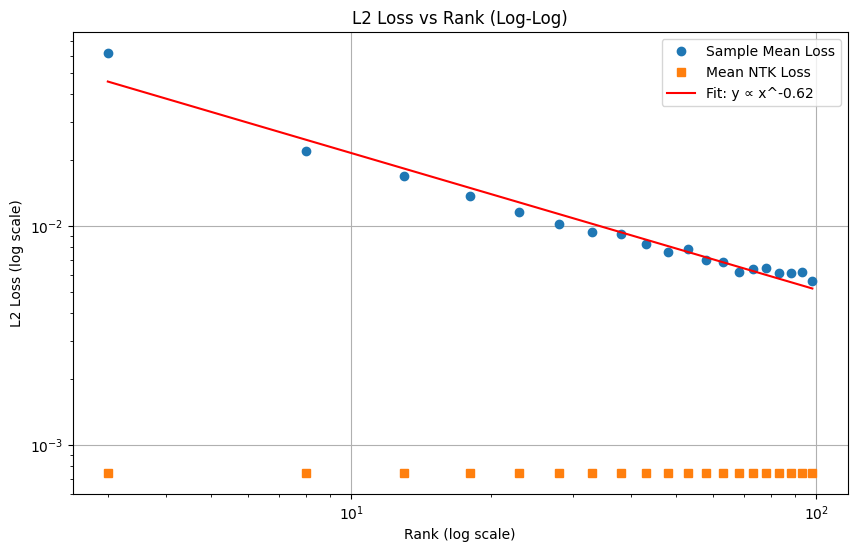

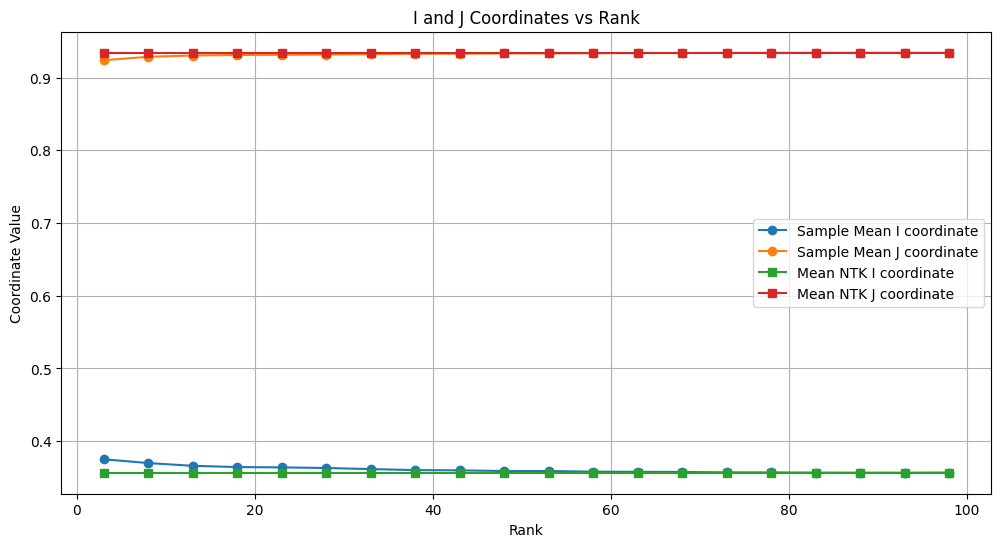

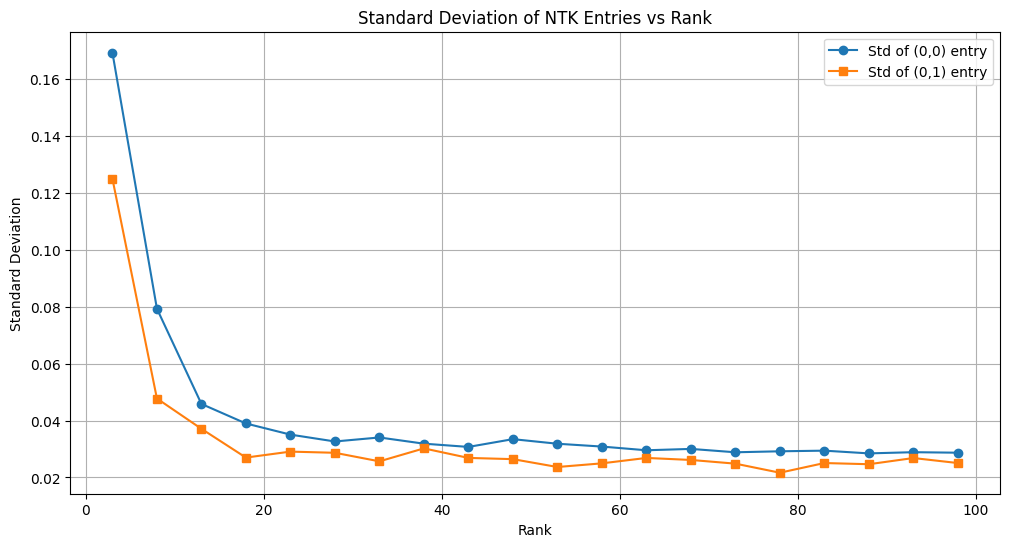

In [ ]:
# we compute mean losses and fit power law
mean_losses = [jnp.mean(jnp.array(l2_losses[rank])) for rank in ranks_to_test]
mean_ntk_losses = [mean_ntk_l2_loss for rank in ranks_to_test]  # we add mean NTK losses
ranks_array = jnp.array(list(ranks_to_test))
log_ranks = jnp.log(ranks_array)
log_losses = jnp.log(jnp.array(mean_losses))

# we fit power law using linear regression in log space
A = jnp.vstack([log_ranks, jnp.ones_like(log_ranks)]).T
m, b = jnp.linalg.lstsq(A, log_losses, rcond=None)[0]
power_law = jnp.exp(b) * ranks_array**m

# we plot L2 loss vs rank in log-log space
plt.figure(figsize=(10, 6))
plt.loglog(ranks_array, mean_losses, 'o', label='Sample Mean Loss')
plt.loglog(ranks_array, mean_ntk_losses, 's', label='Mean NTK Loss')  # we add mean NTK plot
plt.loglog(ranks_array, power_law, 'r-', label=f'Fit: y ∝ x^{m:.2f}')
plt.title('L2 Loss vs Rank (Log-Log)')
plt.xlabel('Rank (log scale)')
plt.ylabel('L2 Loss (log scale)')
plt.legend()
plt.grid(True)
plt.show()

# we plot I and J coordinates vs rank
plt.figure(figsize=(12, 6))
mean_i_coords = [jnp.mean(jnp.array(i_coords[rank])) for rank in ranks_to_test]
mean_j_coords = [jnp.mean(jnp.array(j_coords[rank])) for rank in ranks_to_test]
mean_ntk_i_coords = [mean_ntk_i_coord for rank in ranks_to_test]  # we add mean NTK I coords
mean_ntk_j_coords = [mean_ntk_j_coord for rank in ranks_to_test]  # we add mean NTK J coords

plt.plot(list(ranks_to_test), mean_i_coords, 'o-', label='Sample Mean I coordinate')
plt.plot(list(ranks_to_test), mean_j_coords, 'o-', label='Sample Mean J coordinate')
plt.plot(list(ranks_to_test), mean_ntk_i_coords, 's-', label='Mean NTK I coordinate')  # we add mean NTK I plot
plt.plot(list(ranks_to_test), mean_ntk_j_coords, 's-', label='Mean NTK J coordinate')  # we add mean NTK J plot
plt.title('I and J Coordinates vs Rank')
plt.xlabel('Rank')
plt.ylabel('Coordinate Value')
plt.legend()
plt.grid(True)
plt.show()

# we plot std of NTK entries (0,0) and (0,1) vs rank
plt.figure(figsize=(12, 6))
mean_std_00 = [jnp.mean(jnp.array(ntk_stds_00[rank])) for rank in ranks_to_test]
mean_std_01 = [jnp.mean(jnp.array(ntk_stds_01[rank])) for rank in ranks_to_test]

plt.plot(list(ranks_to_test), mean_std_00, 'o-', label='Std of (0,0) entry')
plt.plot(list(ranks_to_test), mean_std_01, 's-', label='Std of (0,1) entry')
plt.title('Standard Deviation of NTK Entries vs Rank')
plt.xlabel('Rank')
plt.ylabel('Standard Deviation')
plt.legend()
plt.grid(True)
plt.show()